
<font size = "5"> **Day 3: [Spectroscopic Data & ML‑Enabled Analysis](../MLSTEM2026.ipynb)** </font>


<hr style="height:1px;border-top:4px solid #FF8200" />



[Download](https://github.com/gduscher/MLSTEM2026/raw/refs/heads/main/Day%203/3PM_Analyze_CoreLoss_EELS.ipynb)

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
  https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%203/3PM_Analyze_CoreLoss_EELS.ipynb)


# Quantifying Core-Loss Spectra
part of the workshop of 

<font size = "5"> **[Machine Learning in Transmission Electron Microscopy](../MLSTEM2026.ipynb)**</font>


**Day3: Spectroscopic Data & ML‑Enabled Analysis**
<table style="margin-right:auto;margin-left:0px">
  <tr>
    <td>Gerd Duscher </td>
    <td>Sergei Kalinin</td>
  </tr>
  <tr>
    <td colspan="2"><center>Microscopy Facilities</td> 
  </tr>
  
  <tr>
    <td colspan="2"><center>Materials Science & Engineering</td>
    <td></td>
  </tr>
  <tr>
    <td colspan="2"><center>Institute of Advanced Materials & Manufacturing</td>
  </tr>
  <tr>
    <td colspan="2"><center> The University of Tennessee, Knoxville</center> </td>
  </tr>
</table>
        
**June 2026**


## Content
Analyse EELS spectra and spectrum images.This works also on Google Colab.


## Prerequesites

### Install pyTEMlib

If you have not done so in the [Introduction Notebook](_.ipynb), please test and install [pyTEMlib](https://github.com/gduscher/pyTEMlib) and other important packages with the code cell below.





<font size = "5"> **pyTEMlib : [EELS_tools](../4_EELS_Tools.ipynb)** </font>

<hr style="height:1px;border-top:4px solid #FF8200" />




[<img src=https://www.coeuscreativegroup.com/wp-content/uploads/2020/04/download-button.png, width=125>](https://raw.githubusercontent.com/pycroscopy/pyTEMlib/main/notebooks/EELS/Analyse_EELS.ipynb) 

[![OpenInColab](https://colab.research.google.com/assets/colab-badge.svg)](
    https://colab.research.google.com/github/pycroscopy/pyTEMlib/blob/main/notebooks/Spectroscopy/Analyse_EELS.ipynb)
    
part of 

<font size = "5"> **[pyTEMlib](https://pycroscopy.github.io/pyTEMlib/about.html)**</font>

a [pycroscopy](https://pycroscopy.github.io/pycroscopy/about.html) ecosystem package
Notebook by 

Gerd Duscher

Microscopy Facilities
Materials Science & Engineering<br>
Institute of Advanced Materials & Manufacturing<br>
The University of Tennessee, Knoxville


Analyse EELS spectra and spectrum images.

## Content
The main feature in a core-loss EELS spectrum are the ``ionization edges``.

We destinguish between the area under the ionization edges that give us the chemical composition and the shape of the edges which contains information on atomic bonding. The information is obscured by a rather high background, originating from higher energy edges and the tail of the plasmon peaks (convoluted by multiple scattering).

The shape of an ``ionization edge`` represents the momentum resolved density of states (DOS) and is best described with density functional theory or an excitation theory like GW.


>See [Notebook: Analysing Core-Loss Spectra with Drude Theory](https://raw.githubusercontent.com/gduscher/MSE672-Introduction-to-TEM/main/Spectroscopy/CH4_09-Analyse_Core_Loss.ipynb) of the MSE672-Introduction-to-TEM Lecture in my Github account.


## Load important packages

### Check Installed Packages


In [ ]:
import sys
import importlib.metadata
def test_package(package_name):
    """Test if package exists and returns version or -1"""
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = '-1'
    return version

# pyTEMlib setup ------------------
if test_package('pyTEMlib') < '0.2026.6.0':
    print('installing pyTEMlib')
    !{sys.executable} -m pip install pyTEMlib -q --upgrade
# ------------------------------
print('done')

done


### Import all relevant libraries

Please note that the EELS_tools package from pyTEMlib is essential.

In [3]:
%matplotlib ipympl

import sys
import os

if 'google.colab' in sys.modules:    
    from google.colab import output
    from google.colab import drive
    output.enable_custom_widget_manager()
    
import numpy as np
import matplotlib.pylab as plt

import pyTEMlib

# For archiving reasons it is a good idea to print the version numbers out at this point
print('pyTEM version: ',pyTEMlib.__version__)
__notebook__ = 'analyse_core_loss'
__notebook_version__ = '2026_06_19'

if 'google.colab' in sys.modules:
    drive.mount("/content/drive")


pyTEM version:  0.2026.6.0


## Load and plot a spectrum

In [4]:
if 'google.colab' in sys.modules:
    #drive.mount("/content/drive")
    if not os.path.exists('./EELS-Al_LowLoss.dm3'):
        !gdown https://drive.google.com/uc?id=10OD8YuX6_N-bkBIPp3EbE57x3NxmQ3D3 -O EELS-STO.dm3
        !gdown https://drive.google.com/uc?id=17uJ5Iv6ul06AuXGuPSWRlLhlSGetrh6u -O EELS-Al_LowLoss.dm3
        !gdown https://drive.google.com/uc?id=1vpbIF6dd4544Hx_qCmglMu8HR9v8Kwdt -O EELS-BN_CoreLoss.dm3
        !gdown https://drive.google.com/uc?id=1XRvZE0A0f-V3vIjB9ZphljJh8wQBUGM6 -O EELS-BN_LowLoss.dm3
file_widget = pyTEMlib.file_tools.FileWidget('.')

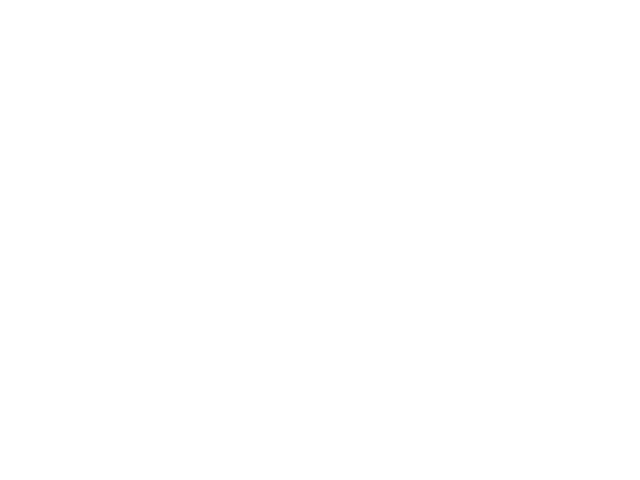

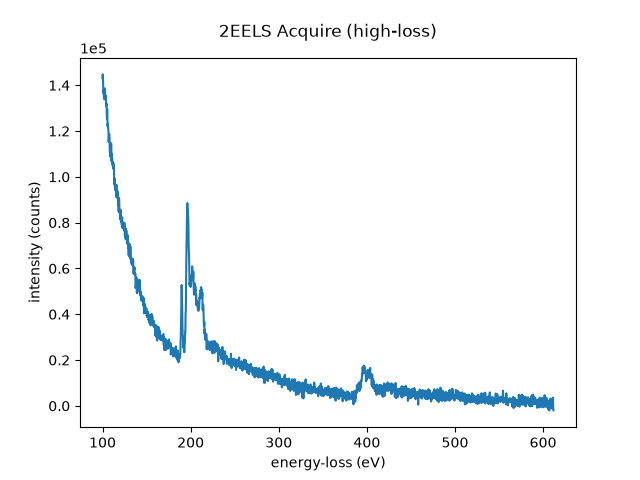

In [57]:
datasets = file_widget.datasets
main_dataset = file_widget.selected_dataset
#plt.close('all')

plt.figure()
v = main_dataset.plot()


In [58]:
main_dataset.view_metadata()


experiment :
	single_exposure_time : 3.0
	exposure_time : 3.01000999977623
	number_of_frames : 21
	convergence_angle : 0.0
	collection_angle : 0.0
	microscope : Unknown
	acceleration_voltage : 200000.0
filename : C:\Users\gduscher\Documents\Github\MLSTEM2026\Day 3\example_data\1EELSAcquire_high-loss.dm3


In [59]:
main_dataset.metadata['experiment']['acceleration_voltage'] = 60000.0

In [60]:
main_dataset.original_metadata['ImageTags']['EELS'].keys()

dict_keys(['Acquisition', 'Experimental Conditions'])

## Fix Energy Scale and Add Necessary Values

We need a correct energy scale and the important values for example convergence and collection angle


energy dispersion = 0.265 eV/channel
onset = 94.7 eV


C:\Users\gduscher\AppData\Local\Temp\ipykernel_38148\1324931938.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  main_dataset.energy_loss/=main_dataset.energy_loss.slope/energy_dispersion
C:\Users\gduscher\AppData\Local\Temp\ipykernel_38148\1324931938.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  main_dataset.energy_loss -= main_dataset.energy_loss[0]-(188-channels[0]*energy_dispersion)


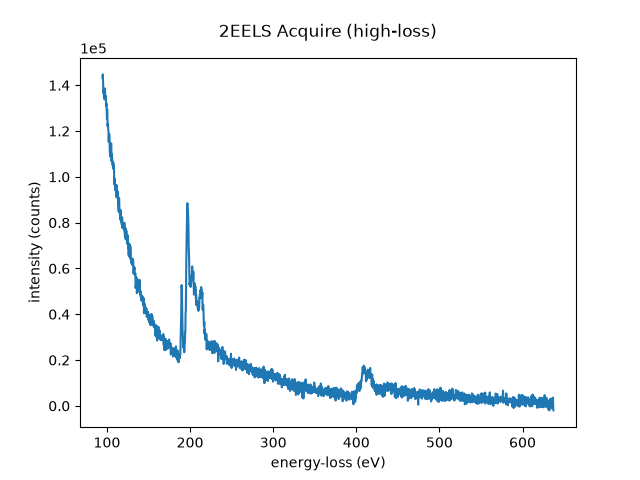

In [61]:


#channels = np.searchsorted(main_dataset.energy_loss, [452, 527])
channels = np.searchsorted(main_dataset.energy_loss, [188, 388])
energy_dispersion= (530-456)/ (channels[1]-channels[0])
energy_dispersion= (400-188)/ (channels[1]-channels[0])

print(f'energy dispersion = {energy_dispersion:.3f} eV/channel')
#print(f'onset = {456-channels[0]*energy_dispersion:.1f} eV')
print(f'onset = {188-channels[0]*energy_dispersion:.1f} eV')

main_dataset.energy_loss/=main_dataset.energy_loss.slope/energy_dispersion
#main_dataset.energy_loss -= main_dataset.energy_loss[0]-(456-channels[0]*energy_dispersion)
main_dataset.energy_loss -= main_dataset.energy_loss[0]-(188-channels[0]*energy_dispersion)

np.array(main_dataset.energy_loss.values[0:4])
main_dataset.energy_loss.dimension_type='SPECTRAL'


main_dataset.metadata['experiment']['collection_angle'] = 0.1
#main_dataset.metadata['experiment']['convergence_angle'] = 30.0
#main_dataset.metadata['experiment']['acceleration_voltage'] = 200.0 * 1000
main_dataset.metadata['experiment']['intentsity_scale_ppm'] = 1.
main_dataset.metadata['experiment']
view = main_dataset.plot()
plt.show()

## Intensity to Probability Calibration

 We need to calibrate the number of counts with the integration time of the spectrum.
### Select Low Loss Spectrum

In [62]:
low_loss_selector = pyTEMlib.file_tools.ChooseDataset(file_widget.datasets)

Dropdown(description='select dataset:', options=('Channel_000: 2EELS Acquire (high-loss)', 'Channel_001: 1EELS…

In [63]:
low_loss_spectrum = low_loss_selector.dataset
view = low_loss_spectrum.plot()
ll = pyTEMlib.eels_tools.align_zero_loss(low_loss_spectrum)
shift = ll.metadata['zero_loss']['shifted']
print(f'zero_loss is {shift[0]:.2f}eV off')


zero_loss is 1.02eV off


###  Probability Calibration

 We need to calibrate the number of counts with the integration time of the spectrum.

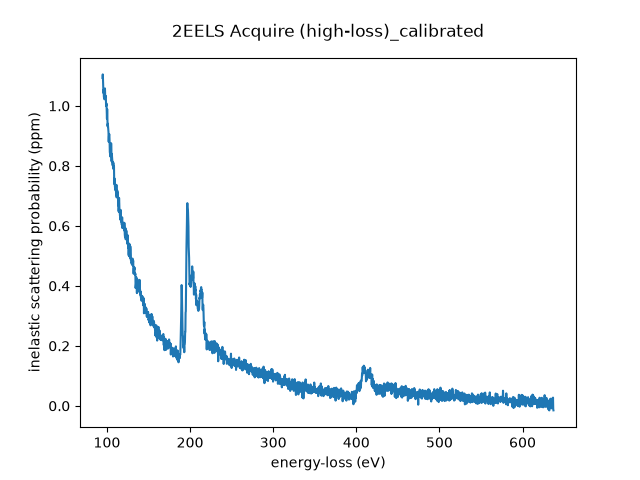

In [64]:
low_loss_exposure_time = low_loss_spectrum.metadata['experiment']['single_exposure_time'] * low_loss_spectrum.metadata['experiment']['number_of_frames']
counts_per_second = low_loss_spectrum.sum()/low_loss_exposure_time
core_loss_exposure_time = main_dataset.metadata['experiment']['single_exposure_time']* main_dataset.metadata['experiment']['number_of_frames']
core_loss_flux   = counts_per_second * core_loss_exposure_time
dispersion = main_dataset.energy_loss.slope
main_dataset.metadata['experiment']['flux'] = counts_per_second
main_dataset.metadata['experiment']['intentsity_scale_ppm'] = 1/core_loss_flux*1e6 * dispersion
main_dataset.metadata['experiment']['incident_beam_current_counts'] = core_loss_flux

dispersion = main_dataset.energy_loss.slope
spectrum = main_dataset * main_dataset.metadata['experiment']['intentsity_scale_ppm'] 
spectrum.title = main_dataset.title+ '_calibrated'
spectrum.quantity = 'inelastic scattering probability'
spectrum. units = 'ppm'
view = spectrum.plot()
# plt.ylim(0,spectrum.max()*1.05)


In [65]:
low_loss_spectrum.metadata['experiment']

{'single_exposure_time': 0.01,
 'exposure_time': 3.01000999977623,
 'number_of_frames': 21,
 'convergence_angle': 0.0,
 'collection_angle': 0.0,
 'microscope': 'Unknown',
 'acceleration_voltage': 200000.0}

## Composition

### Setup of Elements


In [66]:
# ------ Input ---------
elements = ['Ti', 'O']
elements = ['B', 'N']
# ----------------------
main_dataset.metadata.setdefault('core_loss', {})['edges'] ={}
for element in elements:
    pyTEMlib.eels_tools.add_element_to_dataset(main_dataset, element)


Check excluded areas

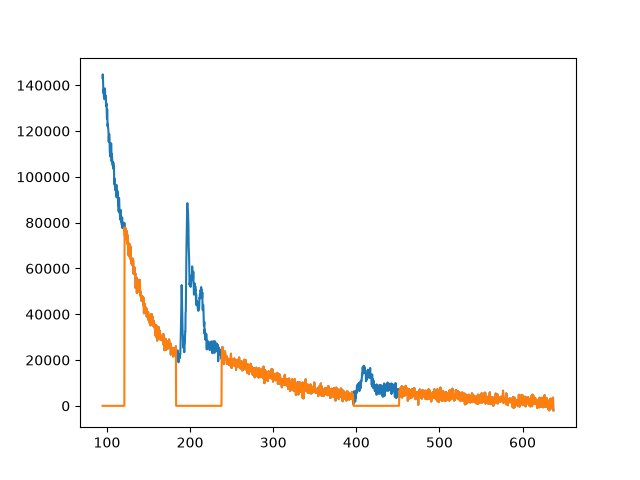

In [67]:
main_dataset.metadata['core_loss'].setdefault('fit_area',{})['fit_start'] = main_dataset.energy_loss.values[100]
mask = pyTEMlib.eels_tools.core_loss_tools.get_mask(main_dataset.energy_loss.values, main_dataset.metadata['core_loss'])
plt.figure()
plt.plot(main_dataset.energy_loss.values, main_dataset)
plt.plot(main_dataset.energy_loss
         .values, main_dataset*mask)
plt.show()

###  Fit of Data


Relative composition: 
B: 47.007%  N: 52.993%  


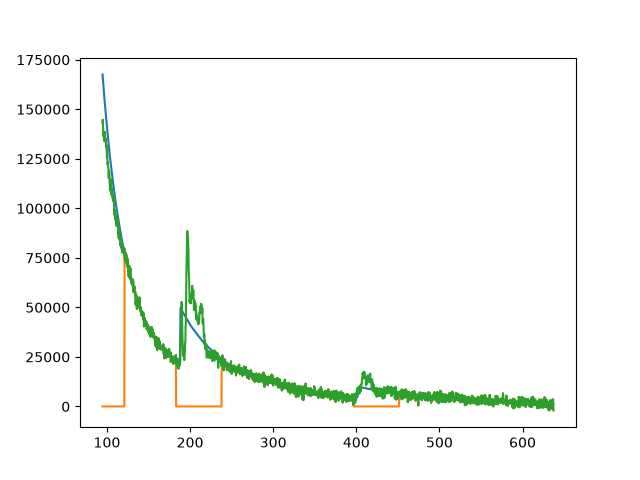

In [68]:
pyTEMlib.eels_tools.fit_dataset(main_dataset)
plt.figure()
plt.plot(main_dataset.energy_loss.values, main_dataset.metadata['core_loss']['model']['spectrum'])
plt.plot(main_dataset.energy_loss.values, main_dataset*mask)
plt.plot(main_dataset.energy_loss.values, main_dataset)
# print(main_dataset.metadata['core_loss']['edges']['3']['onset'])
plt.show()

### Output of Results

In [69]:

edges = main_dataset.metadata['core_loss']['edges']
element = []
areal_density = []

for key, edge in edges.items():
    if key.isdigit():
        element.append(edge['element'])
        areal_density.append(edge['areal_density'])
        
print('Relative chemical composition of ', main_dataset.title)

for i in range(len(element)):
    print(f'{element[i]}: {areal_density[i]/np.sum(areal_density)*100:.3f} %',
          f"areal_density: {areal_density[i]*main_dataset.metadata['experiment']['intentsity_scale_ppm']*1e-6:.2f}atoms/nm^2")
    


Relative chemical composition of  2EELS Acquire (high-loss)
B: 47.007 % areal_density: 15.16atoms/nm^2
N: 52.993 % areal_density: 17.09atoms/nm^2


In [70]:
B_areal_density = edges['0']['areal_density'] *main_dataset.metadata['experiment']['intentsity_scale_ppm']*1e-6
N_areal_density = edges['1']['areal_density'] *main_dataset.metadata['experiment']['intentsity_scale_ppm']*1e-6

#the B atom areal density of a single layer of h-BN (18.2 nm−2) 
print(f" B areal density is {B_areal_density:.0f} atoms per square nm, which equates {abs(B_areal_density)/18.2:.1f} atomic layers")
print(f" N areal density is {N_areal_density:.0f} atoms per square nm, which equates {abs(N_areal_density)/18.2:.1f} atomic layers")

 B areal density is 15 atoms per square nm, which equates 0.8 atomic layers
 N areal density is 17 atoms per square nm, which equates 0.9 atomic layers


In [71]:
main_dataset.metadata['experiment']

{'single_exposure_time': 3.0,
 'exposure_time': 3.01000999977623,
 'number_of_frames': 21,
 'convergence_angle': 0.0,
 'collection_angle': 0.1,
 'microscope': 'Unknown',
 'acceleration_voltage': 60000.0,
 'intentsity_scale_ppm': np.float64(7.634676512680016e-06),
 'flux': np.float32(5.5095315e+08),
 'incident_beam_current_counts': np.float32(3.471005e+10)}

## ELNES
The electron energy-loss near edge structure is determined by fititing the spectrum after quantification model subtraction. 

This will give us a noise free representation of the spectrum


### Smoothing

In [72]:
pyTEMlib.eels_tools.peak_fit_tools.get_gmm(main_dataset, main_dataset.metadata['core_loss']['model']['spectrum'])

C:\Users\gduscher\Documents\Github\MLSTEM2026\.venv\Lib\site-packages\pyTEMlib\eels_tools\peak_fit_tools.py:186: RuntimeWarning: Number of calls to function has reached maxfev = 10000.
  [p, _] = scipy.optimize.leastsq(residuals3, pin, args=(x, y),maxfev = 10000)


np.int64(5)

### Peakfit

dask.array<truediv, shape=(), dtype=float64, chunksize=(), chunktype=numpy.ndarray>
Fitting 10 peaks to spectrum
[ 2.99056908e+01  1.24200349e+06  1.24887623e+01  2.04447783e+02
  1.52199283e+04  1.82882586e+01  1.93666237e+02 -2.66043186e+04
  7.51117189e+00  1.96814156e+02  5.20934983e+04  3.05192135e+00
  1.21686396e+02 -2.92216790e+03  4.74479219e-01  4.12084294e+02
  5.75951740e+03  1.07829904e+01  2.97683296e+02  1.37732529e+03
  3.00084788e+01  1.58466843e+02 -3.53777511e+03  1.08891880e+00
  5.04864043e+02  1.93805753e+03  4.93716376e-01  4.91012400e+02
 -4.68507592e+03  1.96894858e-01]


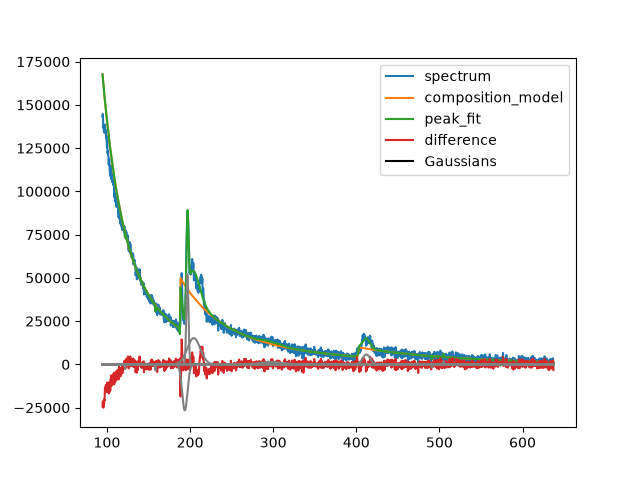

In [73]:
# ------- Input --------
maximum_number_of_peaks = 100
# -----------------------
main_dataset.metadata['peak_fit']['fit_area'] = main_dataset.metadata['core_loss']['fit_area'].copy()
numer_of_peaks = pyTEMlib.eels_tools.peak_fit_tools.find_relevant_peaks(main_dataset, maximum_number_of_peaks )
print(f"Fitting {numer_of_peaks} peaks to spectrum")
pyTEMlib.eels_tools.peak_fit_tools.fit_peaks(main_dataset)
plt.figure()
plt.plot(main_dataset.energy_loss.values, main_dataset, label='spectrum')
plt.plot(main_dataset.energy_loss.values, main_dataset.metadata['peak_fit']['start_model'], label='composition_model')
plt.plot(main_dataset.energy_loss.values, main_dataset.metadata['peak_fit']['start_model']+main_dataset.metadata['peak_fit']['peak_model'], label='peak_fit')
plt.plot(main_dataset.energy_loss.values, main_dataset-(main_dataset.metadata['peak_fit']['start_model']+main_dataset.metadata['peak_fit']['peak_model']), label='difference')
index = 0
plt.plot(main_dataset.energy_loss.values, 
             pyTEMlib.eels_tools.peak_fit_tools.gauss(main_dataset.energy_loss.values, main_dataset.metadata['peak_fit']['peak_out_list'][int(index)]),
             c='black', label='Gaussians')
for index in range(main_dataset.metadata['peak_fit']['peak_out_list'].shape[0]): 
    plt.plot(main_dataset.energy_loss.values, 
             pyTEMlib.eels_tools.peak_fit_tools.gauss(main_dataset.energy_loss.values, main_dataset.metadata['peak_fit']['peak_out_list'][int(index)]),
             c='gray')
plt.legend()
plt.show();

### Output of white-lines

In [74]:
pyTEMlib.eels_tools.find_associated_edges(main_dataset)
out = pyTEMlib.eels_tools.find_white_lines(main_dataset)
out

{'sum': {}, 'ratio': {}}

## Summary

The ioniation edges in a ``Core-Loss spectrum`` reveal the chemical composition and the bonding characteristics of the atoms.  The signal is obscured by a stron background and thin samples are required for a good signal background ratio. 

The cross sections are calculated from a database.

The energy-loss near-edge structure (ELNES) is often only compared through fingerprinting with the literature.


## Appendinx

0 B
1 N


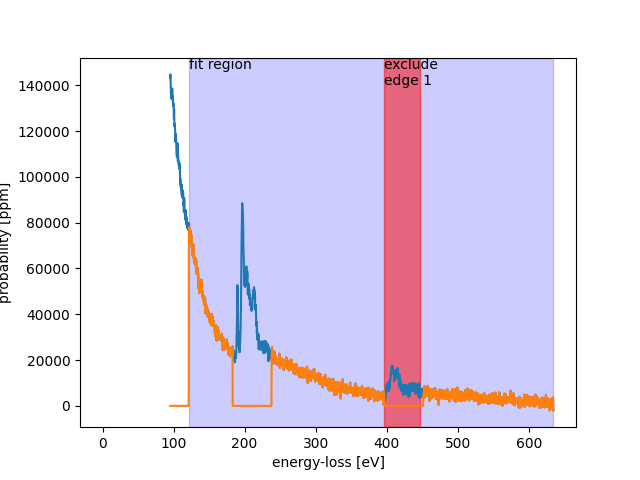

In [33]:
import matplotlib
class RegionSelector(object):
    """
        Selects fitting region and the regions that are excluded for each edge.

        Select a region with a spanSelector and then type 'a' for all of the fitting region or a number for the edge
        you want to define the region excluded from the fit (solid state effects).

        see Chapter4 'CH4-Working_with_X-Sections,ipynb' notebook

    """
    def __init__(self, ax):
        self.ax = ax
        self.regions = {}
        self.rect = None
        self.xmin = 0
        self.xwidth = 0

        self.span = matplotlib.widgets.SpanSelector(ax, self.onselect1, 'horizontal', useblit=True,
                                 props=dict(alpha=0.5, facecolor='red'), interactive=True)# , span_stays=True)
        self.cid = ax.figure.canvas.mpl_connect('key_press_event', self.click)
        self.draw = ax.figure.canvas.mpl_connect('draw_event', self.onresize)

    def onselect1(self, xmin, xmax):
        self.xmin = xmin
        self.width = xmax-xmin

    def onresize(self, event):
        self.update()

    def delete_region(self, key):
        if key in self.regions:
            if 'Rect' in self.regions[key]:
                self.regions[key]['Rect'].remove()
                self.regions[key]['Text'].remove()
            del(self.regions[key])

    def update(self):

        y_min, y_max = self.ax.get_ylim()
        for key in self.regions:
            if 'Rect' in self.regions[key]:
                self.regions[key]['Rect'].remove()
                self.regions[key]['Text'].remove()

            xmin = self.regions[key]['xmin']
            width = self.regions[key]['width']
            height = y_max-y_min
            alpha = self.regions[key]['alpha']
            color = self.regions[key]['color']
            self.regions[key]['Rect'] = matplotlib.patches.Rectangle((xmin, y_min), width, height,
                                                          edgecolor=color, alpha=alpha, facecolor=color)
            self.ax.add_patch(self.regions[key]['Rect'])

            self.regions[key]['Text'] = self.ax.text(xmin, y_max, self.regions[key]['text'], verticalalignment='top')

    def click(self, event):
        if str(event.key) in ['1', '2', '3', '4', '5', '6']:
            key = str(event.key)
            text = 'exclude \nedge ' + key
            alpha = 0.5
            color = 'red'
        elif str(event.key) in ['a', 'A', 'b', 'B', 'f', 'F']:
            key = '0'
            color = 'blue'
            alpha = 0.2
            text = 'fit region'
        else:
            return

        if key not in self.regions:
            self.regions[key] = {}

        self.regions[key]['xmin'] = self.xmin
        self.regions[key]['width'] = self.width
        self.regions[key]['color'] = color
        self.regions[key]['alpha'] = alpha
        self.regions[key]['text'] = text

        self.update()

    def set_regions(self, region, start_x, width):
        if 'fit' in str(region):
            key = '0'
        if region in ['0', '1', '2', '3', '4', '5', '6']:
            key = region
        if region in [0, 1, 2, 3, 4, 5, 6]:
            key = str(region)

        if key not in self.regions:
            self.regions[key] = {}
            if key in ['1', '2', '3', '4', '5', '6']:
                self.regions[key]['text'] = 'exclude \nedge ' + key
                self.regions[key]['alpha'] = 0.5
                self.regions[key]['color'] = 'red'
            elif key == '0':
                self.regions[key]['text'] = 'fit region'
                self.regions[key]['alpha'] = 0.2
                self.regions[key]['color'] = 'blue'

        self.regions[key]['xmin'] = start_x
        self.regions[key]['width'] = width

        self.update()

    def get_regions(self):
        tags = {}
        for key in self.regions:
            if key == '0':
                area = 'fit_area'
            else:
                area = key
            tags[area] = {}
            tags[area]['start_x'] = self.regions[key]['xmin']
            tags[area]['width_x'] = self.regions[key]['width']

        return tags

    def disconnect(self):
        for key in self.regions:
            if 'Rect' in self.regions[key]:
                self.regions[key]['Rect'].remove()
                self.regions[key]['Text'].remove()
        del(self.span)
        self.ax.figure.canvas.mpl_disconnect(self.cid)
        # self.ax.figure.canvas.mpl_disconnect(self.draw)
        pass

energy_scale = main_dataset.energy_loss
spectrum = main_dataset
plt.figure()
plt.plot(energy_scale, spectrum, label='spectrum')
plt.plot(energy_scale, spectrum*mask, label='spectrum')
plt.xlabel('energy-loss [eV]')
plt.ylabel('probability [ppm]');  

regions = RegionSelector(plt.gca())
edges = spectrum.metadata['core_loss']['edges']
for key in edges:
    print(key, edges[key]['element'])
    regions.set_regions(str(key),edges[key]['onset']-5, 50.)
bgd_start = spectrum.metadata['core_loss']['fit_area']['fit_start']                                 
regions.set_regions('fit region',bgd_start, energy_scale[-1]-bgd_start)

## Navigation
- <font size = "3">  **Up Chapter 4: [Imaging](CH4_00-Spectroscopy.ipynb)** </font>
- <font size = "3">  **Back: [Zero-Loss](CH4_02-Fit_Zero_Loss.ipynb)** </font>
- <font size = "3">  **Next: [Introduction to Core-Loss](./CH4_07-Introduction_Core_Loss.ipynb)** </font>
- <font size = "3">  **List of Content: [Front](../_MSE672_Intro_TEM.ipynb)** </font>